In [24]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier

In [1]:
from sklearn.datasets import load_breast_cancer

dataset = load_breast_cancer()

In [4]:
dataset

{'data': array([[1.799e+01, 1.038e+01, 1.228e+02, ..., 2.654e-01, 4.601e-01,
         1.189e-01],
        [2.057e+01, 1.777e+01, 1.329e+02, ..., 1.860e-01, 2.750e-01,
         8.902e-02],
        [1.969e+01, 2.125e+01, 1.300e+02, ..., 2.430e-01, 3.613e-01,
         8.758e-02],
        ...,
        [1.660e+01, 2.808e+01, 1.083e+02, ..., 1.418e-01, 2.218e-01,
         7.820e-02],
        [2.060e+01, 2.933e+01, 1.401e+02, ..., 2.650e-01, 4.087e-01,
         1.240e-01],
        [7.760e+00, 2.454e+01, 4.792e+01, ..., 0.000e+00, 2.871e-01,
         7.039e-02]], shape=(569, 30)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0, 0,
        1, 1, 1, 1, 0, 1, 0, 0, 1, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0,
        1, 1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 1, 0, 1,
        1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 1,

In [5]:
type(dataset)

sklearn.utils._bunch.Bunch

In [3]:
X = dataset.data
y = dataset.target

In [6]:
X = pd.DataFrame(X, columns=dataset.feature_names)
X.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [7]:
y = pd.Series(y)

In [8]:
from sklearn.model_selection import train_test_split

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [17]:
model = DecisionTreeClassifier(max_depth=5)
model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [18]:
y_pred = model.predict(X_test)

In [19]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.94      0.93        63
           1       0.96      0.95      0.96       108

    accuracy                           0.95       171
   macro avg       0.94      0.95      0.94       171
weighted avg       0.95      0.95      0.95       171



In [20]:
from sklearn.tree import plot_tree

In [21]:
dataset.target_names

array(['malignant', 'benign'], dtype='<U9')

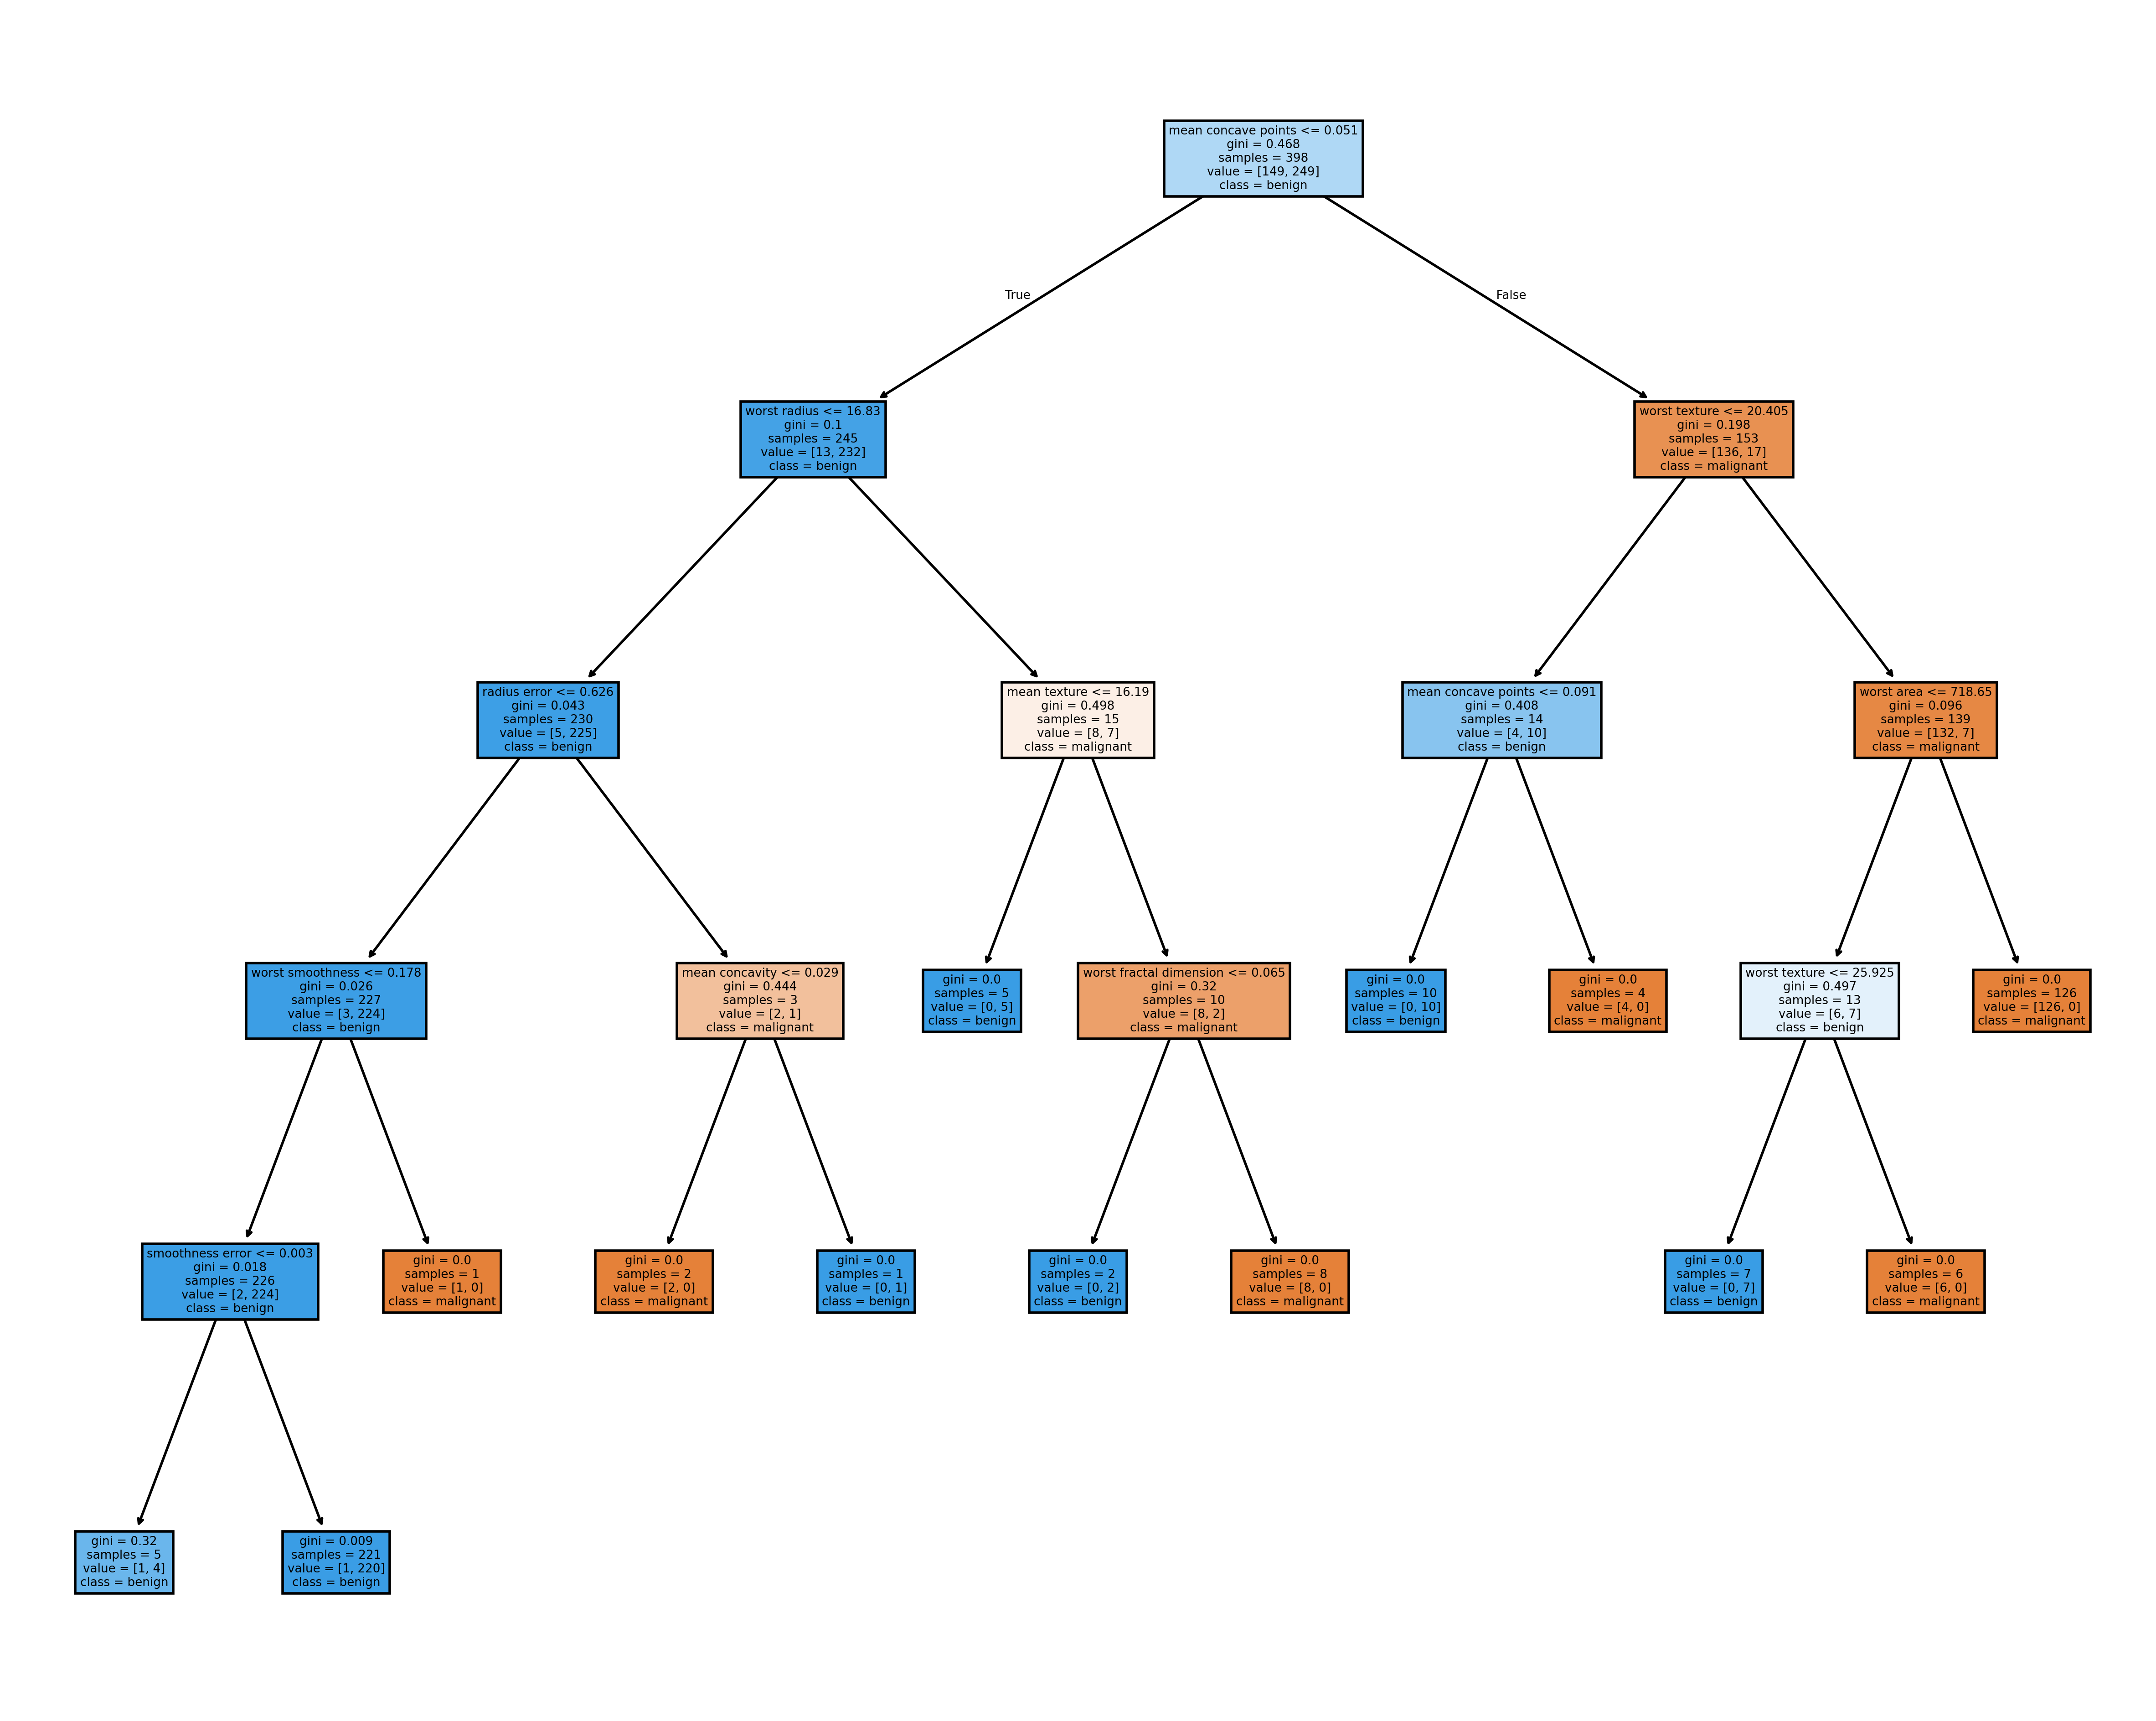

In [22]:
plt.figure(figsize=(15,12), dpi=400)
plot_tree(model, filled=True, feature_names=X.columns, class_names=dataset.target_names)
plt.show()

## Modelos Black Box

In [25]:
model = GradientBoostingClassifier(random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test,  y_pred))

              precision    recall  f1-score   support

           0       0.95      0.94      0.94        63
           1       0.96      0.97      0.97       108

    accuracy                           0.96       171
   macro avg       0.96      0.95      0.96       171
weighted avg       0.96      0.96      0.96       171



In [ ]:
### pip install shap

  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
   ---------------------------------------- 0.0/548.0 kB ? eta -:--:--
   ---------------------------------------- 548.0/548.0 kB 3.7 MB/s  0:00:00
   ---------------------------------------- 0.0/2.7 MB ? eta -:--:--
   ---------------------------------------- 2.7/2.7 MB 17.6 MB/s  0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   ---- ----------------------------------- 4.5/38.1 MB 22.3 MB/s eta 0:00:02
   --------- ------------------------------ 9.4/38.1 MB 23.5 MB/s eta 0:00:02
   --------------------- ------------------ 20.7/38.1 MB 32.7 MB/s eta 0:00:01
   ---------------------------------- ----- 32.8/38.1 MB 39.3 MB/s eta 0:00:01
   ---------------------------------------- 38.1/38.1 MB 39.1 MB/s  0:00:00
Using cached cloudpickle-3.1.2-py3-none-any.whl (22 kB)

   ------------- -------------------------- 2/6 [llvmlite]
   ------------- -------------------------- 2/6 [llvmlite]
   ---

In [28]:
import shap

c:\Users\bianc\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [29]:
explainer = shap.TreeExplainer(model)

In [30]:
shap_values = explainer.shap_values(X_test)

In [31]:
shap_values

array([[-2.53180779e-02,  2.14224419e-02, -1.00984065e-02, ...,
         1.08754317e+00,  6.52031985e-02, -1.09836075e-03],
       [-3.80261400e-02, -9.39265013e-02, -9.29234524e-03, ...,
        -1.90874502e+00,  5.51587832e-02, -1.14623636e-02],
       [-5.23732967e-02, -4.61781771e-02, -2.11701896e-02, ...,
        -9.23735207e-01,  3.64711565e-02, -6.14785345e-03],
       ...,
       [-2.81712640e-02,  1.99554619e-02, -1.50860158e-02, ...,
         1.08853212e+00,  9.04468732e-02, -1.09836075e-03],
       [ 3.05724997e-03, -2.82210546e-01, -7.74298532e-03, ...,
        -1.87033935e+00, -2.98304348e-01,  1.67448730e-04],
       [-2.81147151e-02,  2.57859412e-01, -1.54752377e-02, ...,
        -1.93907728e+00,  9.43667708e-02, -4.33453266e-04]],
      shape=(171, 30))

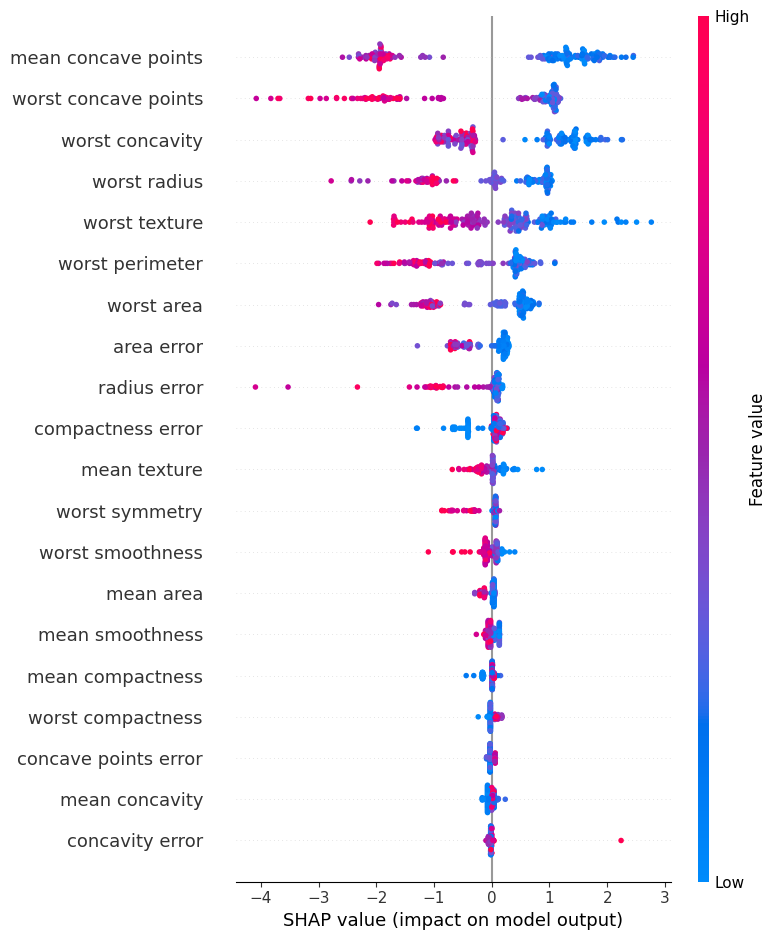

In [32]:
shap.summary_plot(shap_values, X_test)

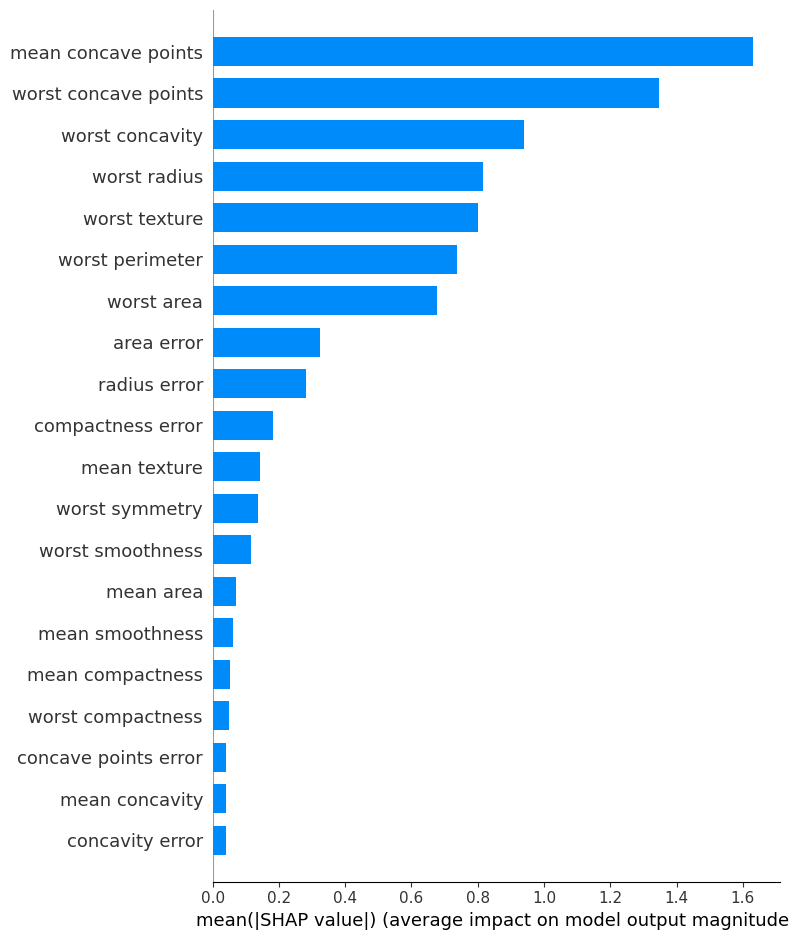

In [33]:
shap.summary_plot(shap_values, X_test, plot_type="bar")